In [1]:
#Імпорт бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

ЗАВАНТАЖЕННЯ ТА ПІДГОТОВКА ДАНИХ

In [2]:
df = pd.read_csv("Corona_NLP_test.csv")

#Вибір колонок
df = df[['OriginalTweet', 'Sentiment']].dropna()

le = LabelEncoder()
y = le.fit_transform(df['Sentiment'])

# Попередня обробка тексту
def preprocess_text(text):
    text = text.lower()  #нижній регістр
    text = re.sub(r"http\S+", "", text)  #видалити посилання
    text = re.sub(r"[^a-zA-Z\s]", "", text)  #лише букви
    tokens = text.split()
    return tokens

X_tokens = df['OriginalTweet'].apply(preprocess_text)

WORD2VEC

In [3]:
w2v_model = Word2Vec(sentences=X_tokens, vector_size=100, window=5, min_count=1, workers=4, seed=42)

#Вктор твіту
def tweet_vector(tokens, model):
    vecs = []
    for token in tokens:
        if token in model.wv:
            vecs.append(model.wv[token])
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    else:
        return np.zeros(model.vector_size)

X_vecs = np.array([tweet_vector(tokens, w2v_model) for tokens in X_tokens])

ПОДІЛ НА TRAIN/TEST

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_vecs, y, test_size=0.2, stratify=y, random_state=42)

МОДЕЛІ

In [5]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "NaiveBayes": GaussianNB()
}

PCA

In [6]:
max_components = min(X_train.shape[0], X_train.shape[1])
pca_components = [50, 100, max_components]

results = {}

for n_comp in [None] + pca_components:
    if n_comp is not None:
        pca = PCA(n_components=n_comp, random_state=42)
        X_train_pca = pca.fit_transform(X_train)
        X_test_pca = pca.transform(X_test)
    else:
        X_train_pca, X_test_pca = X_train, X_test

    results[n_comp] = {}
    for name, model in models.items():
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)

        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
        results[n_comp][name] = {
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1
        }

РЕЗУЛЬТАТИ

In [7]:
for n_comp, metrics_dict in results.items():
    print(f"\n=== PCA components: {n_comp if n_comp is not None else 'None'} ===")
    df_metrics = pd.DataFrame(metrics_dict).T
    print(df_metrics)


=== PCA components: None ===
                    Accuracy  Precision    Recall  F1-score
LogisticRegression  0.297368   0.315022  0.297368  0.226874
SVM                 0.277632   0.205563  0.277632  0.127777
RandomForest        0.293421   0.298451  0.293421  0.287526
NaiveBayes          0.247368   0.283922  0.247368  0.193650

=== PCA components: 50 ===
                    Accuracy  Precision    Recall  F1-score
LogisticRegression  0.293421   0.312940  0.293421  0.224128
SVM                 0.306579   0.250831  0.306579  0.239092
RandomForest        0.363158   0.416984  0.363158  0.344479
NaiveBayes          0.305263   0.314686  0.305263  0.283217

=== PCA components: 100 ===
                    Accuracy  Precision    Recall  F1-score
LogisticRegression  0.293421   0.312575  0.293421  0.224106
SVM                 0.306579   0.250831  0.306579  0.239092
RandomForest        0.361842   0.430329  0.361842  0.330527
NaiveBayes          0.335526   0.341734  0.335526  0.307336


CONFUSION MATRIX

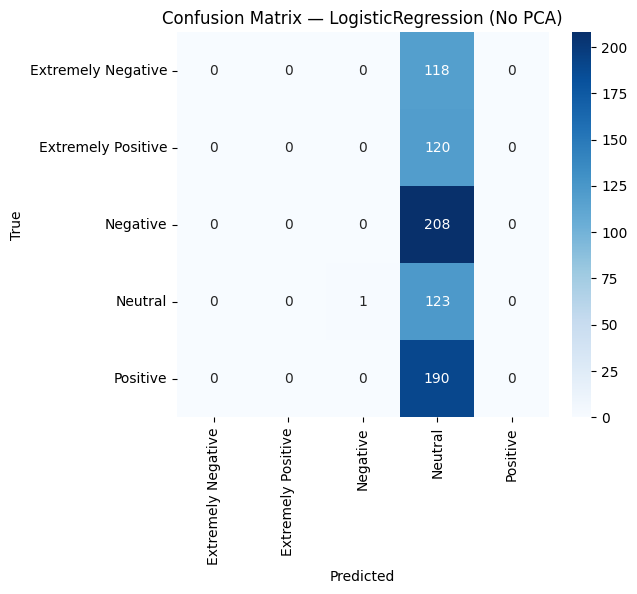

In [8]:
best_model_name = max(results[None], key=lambda k: results[None][k]["Accuracy"])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {best_model_name} (No PCA)")
plt.show()